In [1]:
def trimmed_mean(series, lower_q=0.0, upper_q=1.0):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return series[(series >= lower) & (series <= upper)].mean()

In [33]:
import pickle
import pandas as pd
import numpy as np
from scipy.stats import norm
# 读取pkl文件
fold = 'data_new/'
setting = ["scenario1_500","scenario1_1000","scenario1_2000",\
"scenario2_500","scenario2_1000","scenario2_2000",\
"scenario3_500","scenario3_1000","scenario3_2000",\
"scenario4_500","scenario4_1000","scenario4_2000"]
for m in setting:
    
    with open(fold+m+'.pkl', 'rb') as f:
        data = pickle.load(f)

    bias = np.abs(pd.DataFrame(data)['par'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)
    bias_fSC = np.abs(pd.DataFrame(data)['par_fSC'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)
    bias_SD = np.abs(pd.DataFrame(data)['par_SD'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)
    bias2 = np.abs(pd.DataFrame(data)['par2'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)
    bias2_fSC = np.abs(pd.DataFrame(data)['par2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)
    bias2_SD = np.abs(pd.DataFrame(data)['par2_SD'].replace([np.inf, -np.inf], np.nan).dropna().mean()+0.5)

    
    # SD = ((pd.DataFrame(data)['par'].replace([np.inf, -np.inf], np.nan).dropna().std()))
    # SD_fSC = ((pd.DataFrame(data)['par_fSC'].replace([np.inf, -np.inf], np.nan).dropna().std()))
    # SD_SD  = ((pd.DataFrame(data)['par_SD'].replace([np.inf, -np.inf], np.nan).dropna().std()))
    # SD2 = ((pd.DataFrame(data)['par2'].replace([np.inf, -np.inf], np.nan).dropna().std()))
    # SD2_fSC = ((pd.DataFrame(data)['par2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().std()))       
    # SD2_SD  = ((pd.DataFrame(data)['par2_SD'].replace([np.inf, -np.inf], np.nan).dropna().std()))   

    # SE   = pd.DataFrame(data)['std'].replace([np.inf, -np.inf], np.nan).dropna().mean()
    # SE_fSC   = pd.DataFrame(data)['std_fSC'].replace([np.inf, -np.inf], np.nan).dropna().mean()
    # SE_SD   = pd.DataFrame(data)['std_SD'].replace([np.inf, -np.inf], np.nan).dropna().mean()
    # SE2   = pd.DataFrame(data)['std2'].replace([np.inf, -np.inf], np.nan).dropna().mean()
    # SE2_fSC   = pd.DataFrame(data)['std2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().mean()
    # SE2_SD   = pd.DataFrame(data)['std2_SD'].replace([np.inf, -np.inf], np.nan).dropna().mean()

    SD = ((pd.DataFrame(data)['par'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)
    SD_fSC = ((pd.DataFrame(data)['par_fSC'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par_fSC'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)
    SD_SD  = ((pd.DataFrame(data)['par_SD'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par_SD'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)
    SD2 = ((pd.DataFrame(data)['par2'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par2'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)
    SD2_fSC = ((pd.DataFrame(data)['par2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)       
    SD2_SD  = ((pd.DataFrame(data)['par2_SD'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.75)\
                -pd.DataFrame(data)['par2_SD'].replace([np.inf, -np.inf], np.nan).dropna().quantile(0.25))/1.34898)    
    
    SE   = pd.DataFrame(data)['std'].replace([np.inf, -np.inf], np.nan).dropna().median()
    SE_fSC   = pd.DataFrame(data)['std_fSC'].replace([np.inf, -np.inf], np.nan).dropna().median()
    SE_SD   = pd.DataFrame(data)['std_SD'].replace([np.inf, -np.inf], np.nan).dropna().median()
    SE2   = pd.DataFrame(data)['std2'].replace([np.inf, -np.inf], np.nan).dropna().median()
    SE2_fSC   = pd.DataFrame(data)['std2_fSC'].replace([np.inf, -np.inf], np.nan).dropna().median()
    SE2_SD   = pd.DataFrame(data)['std2_SD'].replace([np.inf, -np.inf], np.nan).dropna().median()

    CR95 = np.mean(np.abs((pd.DataFrame(data)['par']+0.5)/pd.DataFrame(data)['std']) < norm.ppf(0.975))
    CR95_fSC = np.mean(np.abs((pd.DataFrame(data)['par_fSC']+0.5)/pd.DataFrame(data)['std_fSC']) < norm.ppf(0.975))
    CR95_SD = np.mean(np.abs((pd.DataFrame(data)['par_SD']+0.5)/pd.DataFrame(data)['std_SD']) < norm.ppf(0.975))
    CR952 = np.mean(np.abs((pd.DataFrame(data)['par2']+0.5)/pd.DataFrame(data)['std2']) < norm.ppf(0.975))
    CR952_fSC = np.mean(np.abs((pd.DataFrame(data)['par2_fSC']+0.5)/pd.DataFrame(data)['std2_fSC']) < norm.ppf(0.975))
    CR952_SD = np.mean(np.abs((pd.DataFrame(data)['par2_SD']+0.5)/pd.DataFrame(data)['std2_SD']) < norm.ppf(0.975))
    print('case',m.replace('scenario','').replace('_',', n = '))
    print(pd.DataFrame(
        [
            [bias,      SD,      SE,      SE / SD,          CR95],
            [bias_SD,   SD_SD,   SE_SD,   SE_SD / SD_SD,    CR95_SD],
            [bias_fSC,  SD_fSC,  SE_fSC,  SE_fSC / SD_fSC,  CR95_fSC],
            [bias2,     SD2,     SE2,     SE2 / SD2,        CR952],
            [bias2_SD,  SD2_SD,  SE2_SD,  SE2_SD / SD2_SD,  CR952_SD],
            [bias2_fSC, SD2_fSC, SE2_fSC, SE2_fSC / SD2_fSC, CR952_fSC],
        ],
        index=["true", "SD", "fSC", "true2", "SD2", "fSC2"],
        columns=["Bias", "SD", "SE", "SE/SD", "CR"],
    ).to_string(float_format=lambda x: f"{x:.4f}"))
    print()


case 1, n = 500
        Bias     SD     SE  SE/SD     CR
true  0.0151 0.1676 0.1544 0.9215 0.9820
SD    0.1114 0.1410 0.1401 0.9932 0.8640
fSC   0.1593 0.2038 0.2744 1.3462 0.9980
true2 0.0511 0.1394 0.1393 0.9998 0.9700
SD2   0.1012 0.1170 0.1319 1.1270 0.9160
fSC2  0.1637 0.1695 0.2472 1.4589 0.9940

case 1, n = 1000
        Bias     SD     SE  SE/SD     CR
true  0.0045 0.0923 0.0972 1.0531 0.9560
SD    0.0727 0.0906 0.0937 1.0349 0.8940
fSC   0.0801 0.1273 0.1629 1.2794 0.9940
true2 0.0155 0.0906 0.0883 0.9746 0.9600
SD2   0.0626 0.0872 0.0875 1.0031 0.9060
fSC2  0.0714 0.1103 0.1559 1.4131 0.9920

case 1, n = 2000
        Bias     SD     SE  SE/SD     CR
true  0.0002 0.0684 0.0654 0.9560 0.9580
SD    0.0486 0.0653 0.0645 0.9877 0.8900
fSC   0.0378 0.0821 0.1081 1.3167 0.9940
true2 0.0085 0.0568 0.0598 1.0515 0.9500
SD2   0.0412 0.0552 0.0600 1.0877 0.9020
fSC2  0.0380 0.0677 0.1050 1.5498 0.9940

case 2, n = 500
        Bias     SD     SE  SE/SD     CR
true  0.0968 0.2342 0.2403 1.

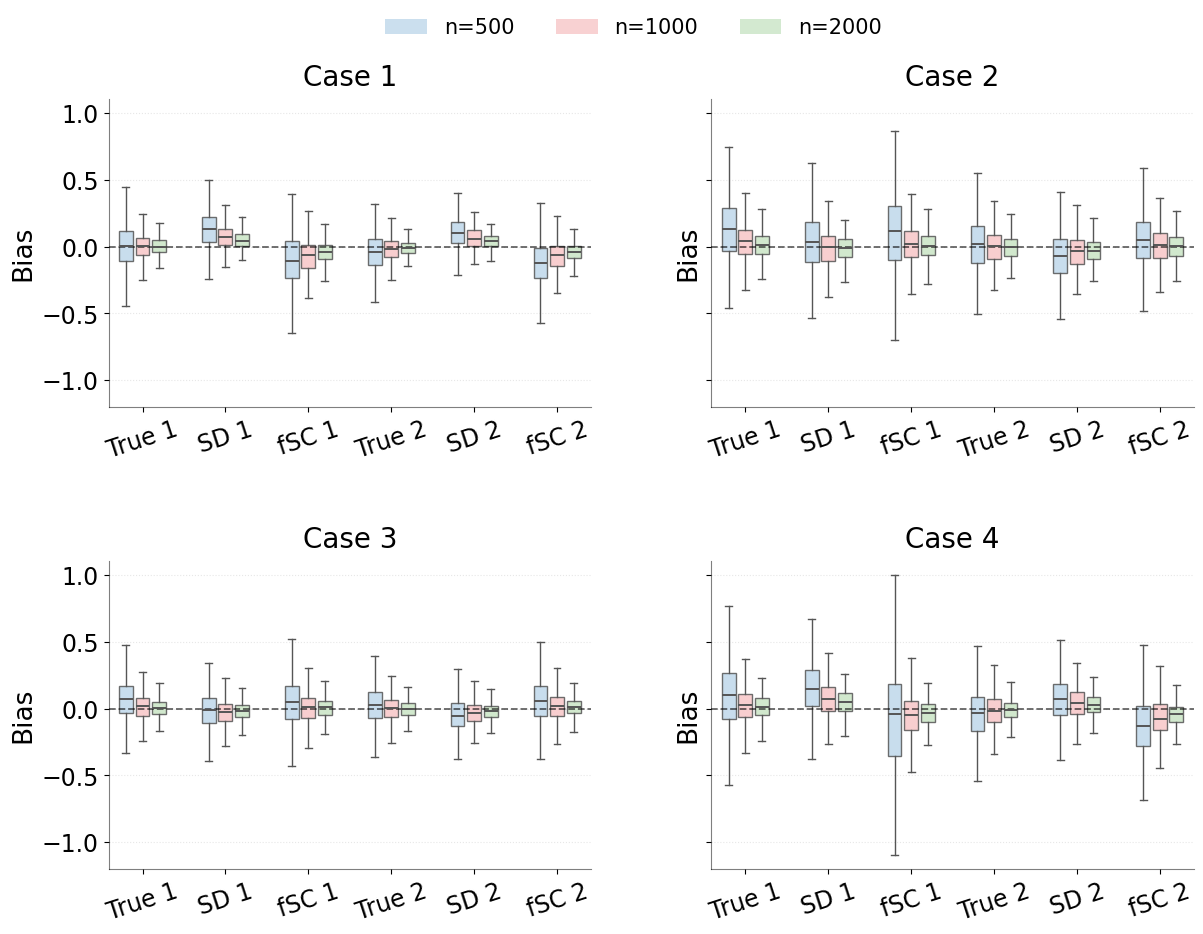

In [3]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.style.use("default")

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 19,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 15,
    "figure.titlesize": 22
})

fold = "data_new/"

setting_pairs = [
    ("scenario1_500", "scenario1_1000", "scenario1_2000"),
    ("scenario2_500", "scenario2_1000", "scenario2_2000"),
    ("scenario3_500", "scenario3_1000", "scenario3_2000"),
    ("scenario4_500", "scenario4_1000", "scenario4_2000")
]

sample_sizes = [500, 1000, 2000]

methods = [
    ("True 1", "par"),
    ("SD 1", "par_SD"),
    ("fSC 1", "par_fSC"),
    ("True 2", "par2"),
    ("SD 2", "par2_SD"),
    ("fSC 2", "par2_fSC")
]

colors = ["#BFD7EA", "#F7C6C7", "#C9E4C5"]
edge = "#555555"

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=True
)

axes = axes.flatten()

for ax, scenarios in zip(axes, setting_pairs):

    # 每个 case 的三个样本量只读取一次
    data_by_n = {}
    for scenario, n_i in zip(scenarios, sample_sizes):
        with open(os.path.join(fold, f"{scenario}.pkl"), "rb") as f:
            data_by_n[n_i] = pd.DataFrame(pickle.load(f))

    all_data = []
    positions = []

    gap = 2.4
    offsets = [-0.48, 0.0, 0.48]
    width = 0.40

    for i, (_, col) in enumerate(methods):
        center = i * gap

        for offset, n_i in zip(offsets, sample_sizes):
            bias = (
                data_by_n[n_i][col]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                + 0.5
            )

            all_data.append(bias)
            positions.append(center + offset)

    bp = ax.boxplot(
        all_data,
        positions=positions,
        widths=width,
        patch_artist=True,
        showfliers=False,
        whiskerprops=dict(color=edge, linewidth=1),
        capprops=dict(color=edge, linewidth=1),
        boxprops=dict(color=edge, linewidth=1),
        medianprops=dict(color=edge, linewidth=1.4)
    )

    # 每个 method 下有 3 个 n，对应三个颜色
    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(colors[i % len(sample_sizes)])
        box.set_alpha(0.85)

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.3,
        color="black",
        alpha=0.6
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.8,
        alpha=0.3
    )

    ax.set_xticks(np.arange(len(methods)) * gap)
    ax.set_xticklabels([m[0] for m in methods], rotation=18)

    case_num = scenarios[0].split("_")[0].replace("scenario", "")
    ax.set_title(f"Case {case_num}", pad=10)

    ax.set_ylabel("Bias")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.5)
    ax.spines["bottom"].set_alpha(0.5)

legend_handles = [
    Patch(facecolor=color, edgecolor="none", alpha=0.8, label=f"n={n_i}")
    for color, n_i in zip(colors, sample_sizes)
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False
)

plt.subplots_adjust(
    wspace=0.25,
    hspace=0.50
)

save_path = "simu_result"

fig.savefig(
    f"{save_path}.pdf",
    bbox_inches="tight"
)

plt.show()